# Kommentarer på vad vi ska göra

* Vi kan ha en champion för varje och säga att vi hitta genom att göra CV samt med grid search, man kan nämnn generellt vad man testat

* Komma på vilken metric är vettig att dra resultat av och ge till user

* Ha några plots, som train/val loss, confusion matrix och vad mer vi tycker är intressant

* Ha animering på video på cut video?? 

* Om tid finns kanske lägga till conv NN

* Göra allt för Kinect och media pipe data, ha olika champions då borde vara bäst?? Jämföra med varandra


# Sebastians generella instruktioner från moodle 

* Submit a single, self-contained, and fully runnable notebook - I do run and debug all of your notebooks. While I do inspect your repositories, you must not rely on me trying to find where the training code is, it needs to be in the notebook.

* Do not include the datasets or pre-rendered plots. Do not put Python in formatted markdown cells. Once I run the notebook, it computes all results. If your notebook relies on earlier results or produced data, you should include it though.

* Of course you can keep the reporting for all trained variants and champion models, etc. But the notebook needs to contain one runnable version of each variant so to speak.

* Submit just the notebook, not a Zip. Only a Zip if your notebook requires auxiliary files to run.

## Handle all inputs

In [100]:
import torch.nn as nn
import torch
import mlflow
import random
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score
from datetime import datetime
from sklearn.model_selection import KFold
import torch.optim as optim
import json
import os
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
## lägg till allt som används

## Setup

In [101]:
if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

# make sure everything has same seeds
random_seed = 42
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


#mlflow.set_tracking_uri("http://127.0.0.1:5000")
#mlflow.set_experiment("Squat_or_not")
#mlflow.enable_system_metrics_logging()

## Create the new Y value using the kinetic cut as reference

We generate frame-level movement labels by aligning full length videos with their manually trimmed counterparts. For each video, frames present in the trimmed version are labeled as movement (1), while all other frames are labeled as non-movement (0). The resulting labeled full sequences are then saved for use in supervised model training.

In [141]:
def add_frame_overlap_column(full_csv_path, trimmed_csv_path, column_name="running_video"):
    df_full = pd.read_csv(full_csv_path)
    df_trimmed = pd.read_csv(trimmed_csv_path)

    trimmed_frames = set(df_trimmed["FrameNo"].values)

    values = []

    for frame in df_full["FrameNo"]:
        if frame in trimmed_frames:
            values.append(1)
        else:
            values.append(0)

    df_full[column_name] = values


    return df_full

In [145]:
trimmed_dir = "../data/kinect_good_preprocessed"

full_dir = "data/kinect_good_preprocessed_not_cut"
output_dir = "data/kinect_good_preprocessed_not_cut_start_stop"

# Paths for mediapipe
#full_dir = "../Assignment10/data/csv_of_all_videos"
#output_dir = "data/mediapipe_not_cut_start_stop"

for file_name in os.listdir(full_dir):
    if file_name.endswith(".csv"):

        full_path = os.path.join(full_dir, file_name)
        trimmed_path = os.path.join(trimmed_dir, file_name)

        if not os.path.exists(trimmed_path):
            print(f"Skipping (no match): {file_name}")
            continue

        df = add_frame_overlap_column(full_path, trimmed_path)

        output_path = os.path.join(output_dir, file_name)
        df.to_csv(output_path, index=False)

        print(f"Saved: {file_name}")

Saved: A100_kinect.csv
Saved: A11_kinect.csv
Saved: A26_kinect.csv
Saved: A137_kinect.csv
Saved: A73_kinect.csv
Saved: B9_kinect.csv
Saved: A155_kinect.csv
Saved: A44_kinect.csv
Saved: A90_kinect.csv
Saved: A149_kinect.csv
Saved: A58_kinect.csv
Saved: B4_kinect.csv
Saved: A158_kinect.csv
Saved: A3_kinect.csv
Saved: A49_kinect.csv
Saved: B17_kinect.csv
Saved: B20_kinect.csv
Saved: A81_kinect.csv
Saved: A144_kinect.csv
Saved: A55_kinect.csv
Saved: A62_kinect.csv
Saved: A37_kinect.csv
Saved: A126_kinect.csv
Saved: A111_kinect.csv
Saved: A84_kinect.csv
Saved: B12_kinect.csv
Saved: A6_kinect.csv
Saved: B1_kinect.csv
Saved: A108_kinect.csv
Saved: A19_kinect.csv
Saved: A98_kinect.csv
Saved: A67_kinect.csv
Saved: A141_kinect.csv
Saved: A50_kinect.csv
Saved: A114_kinect.csv
Saved: A32_kinect.csv
Saved: A123_kinect.csv
Saved: A23_kinect.csv
Saved: A132_kinect.csv
Saved: A105_kinect.csv
Saved: A14_kinect.csv
Saved: A150_kinect.csv
Saved: A41_kinect.csv
Saved: A76_kinect.csv
Saved: A89_kinect.csv


## Load data 

* First load from chosen folder 
* Split into X and Y ignore frame NO feature
* Do normalisation with base in train data on all partitions




In [102]:
def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files
    

def input_target_split_start_stop(dataframe):

    joints = [
        "head", "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot" ]

    input_col_names = []

    for joint in joints:
        input_col_names += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    X = dataframe[input_col_names].copy()
    y = dataframe[["running_video"]].copy()

    return X, y

def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined


In [103]:
data_folder = "data/kinect_good_preprocessed_not_cut_start_stop"

training_prop = 0.9
validation_prop = 0
train_files, test_files = split_csvfiles(data_folder, random_seed, training_prop, validation_prop)

# Load in combined dataframe of all the files kept in the specific split
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)


# Split input (x, y, z) and target (running_video)
x_train, y_train = input_target_split_start_stop(train_data)
x_test, y_test = input_target_split_start_stop(test_data)

# Normalize data with the training scale
scaler = StandardScaler()
x_train_np = x_train.values
x_test_np = x_test.values

x_train_scaled = scaler.fit_transform(x_train_np)
x_test_scaled = scaler.transform(x_test_np)  # use same scaler

# Convert to tensors for the 
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)

# **Feed forward network**


## Functions for the implementation

In [104]:
# Function to load champion model/ best performing model
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# Function for saving a model as our current champion model
def save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters):
    model_path = os.path.join(champion_dir, "champion_model.pt")
    info_path = os.path.join(metadata_dir, "champion_info.json")

    # Save model weights
    torch.save(model.state_dict(), model_path)

    # Save metadata
    info = {
        "model_name": model_name,
        "saved_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "f1": float(f1),
        "recall": float(recall),
        "precision": float(precision),
        "hyperparameters": hyperparameters
    }

    with open(info_path, "w") as f:
        json.dump(info, f, indent=2)

    print("New champion model saved!")


# Function that saves a model as champion uisng the save_champion_model function if either 1. We have no champion, 2. New model is better
def update_champion(metadata_dir, champion_dir, model, model_name, f1, recall, precision, hyperparameters):
    current = load_champion_info(metadata_dir)

    if current is None:
        print("No champion found --> saving first model")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)

    elif f1 > current["f1"]:
        print(f"New model is better (f1 {f1} > {current['f1']})")
        save_champion_model(champion_dir, metadata_dir, model, model_name, f1, recall, precision, hyperparameters)

    else:
        print(f"Model NOT better (f1 {f1} < {current['f1']})")


# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)


# Define Feedforward squat classifier class
class Squatclassifier(nn.Module):
    def __init__(self, input_size, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        act = activations[activation]
        prev_size = input_size

        # Hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act)

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer- 1 neuron
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)
    
    def forward(self, X):
        return self.network(X)
        

# Initializes a squatclassifier model based on a configuration
def build_model(config):
    return Squatclassifier(
        input_size=config["input_size"],
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Train the model
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_f1 = 0
    best_state = None
    patience = 10
    epochs_no_improve = 0

    # reshape targets
    y_train = y_train.view(-1, 1)
    y_val = y_val.view(-1, 1)

    # Training loop (full-batch)
    for epoch in range(epochs):

        model.train()
        optimizer.zero_grad()

        logits = model(x_train)
        loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()

        with torch.no_grad():
            val_logits = model(x_val)
            probs = torch.sigmoid(val_logits)
            preds = (probs > 0.5).float()

            val_f1 = f1_score(
                y_val.cpu().numpy(),
                preds.cpu().numpy()
            )

        # Early stopping on f1-score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    return best_val_f1, best_state


# Cross validation function
def cross_validation(config, X, Y, k):

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []

    # Train and evaluate on each fold
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        x_train = X[train_idx].to(device)
        y_train = Y[train_idx].to(device)

        x_val = X[val_idx].to(device)
        y_val = Y[val_idx].to(device)

        # Build model
        model = build_model(config)


        val_f1, best_state = train_one_model(
            model,
            config,
            x_train,
            y_train,
            x_val,
            y_val,
            # Binary Cross Entropy/Log Loss
            loss_fn=nn.BCEWithLogitsLoss()
        )

        fold_scores.append(val_f1)
        fold_models.append(best_state)


    avg_f1 = sum(fold_scores) / len(fold_scores)


    return {
        "cv_mean_f1": avg_f1,
        "fold_scores": fold_scores,
        "fold_models": fold_models
    }

## Setup

In [105]:
# Gridsearch and cross validation where we decided upon the hyperparameter is in HugoProject/notebooks/assignment11_hugo.ipynb

# Access where best FNN classificator is stored
model_root = "binary_classificator_models/fnn_classificator"
metadata_path = os.path.join(model_root, "metadata")


champion_info = load_champion_info(metadata_path)
best_config = champion_info["hyperparameters"]
print("Champion config loaded")
print(best_config)


# Alternatively here is the config stored in local variable
# best_config = {"model_name": "final_model",
#                "saved_at": "2026-04-28 20:11:13",
#                "f1": 0.9239302694136292,
#                "recall": 0.938430583501006,
#                "precision": 0.9098712446351931,
#                "hyperparameters": {
#                 "layers": [
#                   256,
#                   128,
#                   32
#                 ],
#                 "lr": 0.005,
#                 "dropout": 0.1,
#                 "activation": "relu",
#                 "epochs": 200,
#                 "input_size": 39
#                 }
# }

Champion config loaded
{'layers': [256, 128, 32], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}


## Re-train

In [106]:
# Rebuild best model from cross validation grid search
final_model = build_model(best_config)

# Make split for the retraining s.t model isn't overfitted to the training data
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)


# Retrain best config from the cross validation gridsearch
_, best_state = train_one_model(final_model, best_config, x_tr, y_tr, x_val, y_val, loss_fn = nn.BCEWithLogitsLoss())



## Evaluate and results



TEST RESULTS
F1: 0.9103387203896391
Precision: 0.8771331058020477
Recall: 0.9461573861021629
Accuracy: 89.8649%

Confusion Matrix for best performing FNN:


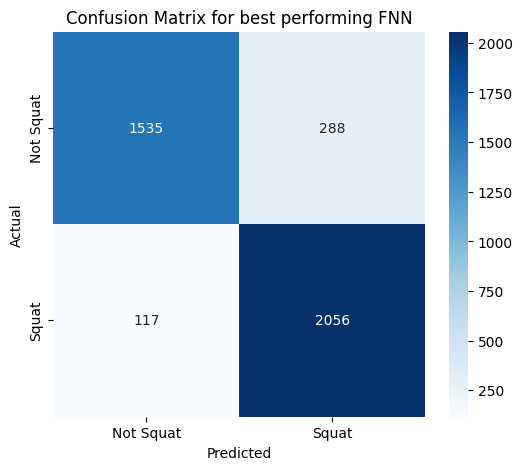

In [107]:
# Load weights from re-training
final_model.load_state_dict(best_state)

# Evaluate against test set
final_model.eval()
with torch.no_grad():
    logits = final_model(x_test.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    f1 = f1_score(y_test.cpu(), preds.cpu())
    precision = precision_score(y_test.cpu(), preds.cpu())
    recall = recall_score(y_test.cpu(), preds.cpu())
    accuracy = accuracy_score(y_test.cpu(), preds.cpu())

    cm = confusion_matrix(y_test.cpu(), preds.cpu())

print("TEST RESULTS")
print(f"F1: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {round(accuracy * 100, 4)}%")
print("\nConfusion Matrix for best performing FNN:")

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Squat", "Squat"],
            yticklabels=["Not Squat", "Squat"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for best performing FNN")
plt.show()

# Reccurant NN

## Setup

## Train

## Evaluate and results


# Cut video (Kinect) 

This step applies the trained classification model to unseen full (uncut) videos to automatically identify movement segments. The model predicts a probability for each frame, which is converted into binary labels using a threshold. Based on these predictions, the start and end of the movement are determined, and the corresponding frames are extracted to create a trimmed version of the video. This demonstrates the model’s ability to replace manual trimming with an automated pipeline.

In [148]:
def trim_csv_with_model_simple(model, input_csv, output_csv, threshold=0.5):
    df = pd.read_csv(input_csv)
    df.columns = df.columns.str.strip()
    
    if "FrameNo" not in df.columns:
        df["FrameNo"] = np.arange(len(df))


    feature_cols = [c for c in df.columns
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z")]


    X_np = df[feature_cols].values
    X_scaled = scaler.transform(X_np)
    X = torch.tensor(X_scaled, dtype=torch.float32).to(device)
    
    model.eval()
    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits).cpu().numpy().flatten()

    preds = (probs >= threshold).astype(int)

    print("Predictions of relevant frames:")
    print(preds)
    
    df["pred_running"] = preds

    movement_frames = df[df["pred_running"] == 1]

    if len(movement_frames) == 0:
        print("No movement detected")
        return None

    start_idx = movement_frames.index.min()
    stop_idx = movement_frames.index.max()

    trimmed_df = df.loc[start_idx:stop_idx].drop(columns=["pred_running"])

    trimmed_df.to_csv(output_csv, index=False)

    print(f"Saved trimmed CSV: {output_csv}")
    print(f"Start index: {start_idx}, Stop index: {stop_idx}")

    return trimmed_df

In [120]:
# Files to test to cut
print(test_files)


['B21_kinect.csv', 'A146_kinect.csv', 'A157_kinect.csv', 'A111_kinect.csv', 'A44_kinect.csv', 'A90_kinect.csv', 'A151_kinect.csv', 'A20_kinect.csv', 'A126_kinect.csv', 'A31_kinect.csv', 'A6_kinect.csv', 'A32_kinect.csv', 'B18_kinect.csv', 'A35_kinect.csv', 'A52_kinect.csv', 'A155_kinect.csv', 'A108_kinect.csv', 'A12_kinect.csv']


In [ ]:
input_path = "data/kinect_good_preprocessed_not_cut/B21_kinect.csv"
output_path = "../data/kinect_own_trimmed/B21_kinnect_trimmed.csv"

trim_csv_with_model_simple(
    model=final_model,
    input_csv=input_path,
    output_csv=output_path
)

Predictions of relevant frames:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
Saved trimmed CSV: ../data/kinect_own_trimmed/B21_kinnect_trimmed.csv
Start index: 111, Stop index: 200


,FrameNo,head_x,head_y,head_z,left_shoulder_x,left_shoulder_y,left_shoulder_z,left_elbow_x,left_elbow_y,left_elbow_z,...,left_knee_z,right_knee_x,right_knee_y,right_knee_z,left_foot_x,left_foot_y,left_foot_z,right_foot_x,right_foot_y,right_foot_z
111,111,-0.009925,0.73393,0.032995,-0.15909,0.54519,-0.007979,-0.26413,0.74659,-0.089940,...,-0.051519,0.10954,-0.34084,-0.020723,-0.10152,-0.68682,0.019142,0.094830,-0.66792,0.042388
112,112,-0.009925,0.72492,0.032995,-0.15864,0.53478,-0.007149,-0.26381,0.73657,-0.090440,...,-0.055958,0.11157,-0.34452,-0.025678,-0.10155,-0.68972,0.016642,0.095111,-0.67055,0.040269
113,113,-0.009970,0.71432,0.032993,-0.15818,0.52310,-0.006174,-0.26352,0.72556,-0.090514,...,-0.060662,0.11365,-0.34847,-0.031300,-0.10163,-0.69285,0.014134,0.095554,-0.67342,0.037777
114,114,-0.010223,0.70202,0.033192,-0.15778,0.50989,-0.004985,-0.26345,0.71403,-0.090598,...,-0.066008,0.11565,-0.35268,-0.037151,-0.10159,-0.69598,0.011468,0.095977,-0.67651,0.035055
115,115,-0.010635,0.68898,0.033549,-0.15771,0.49798,-0.003977,-0.26344,0.70084,-0.090942,...,-0.071443,0.11767,-0.35766,-0.043375,-0.10150,-0.69894,0.008577,0.096474,-0.67965,0.032154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,196,-0.000990,0.71872,0.034948,-0.14619,0.51411,-0.008503,-0.25181,0.71429,-0.092726,...,-0.084491,0.12232,-0.29878,-0.069755,-0.10532,-0.66657,-0.011768,0.108800,-0.67127,-0.017156
197,197,-0.000905,0.73340,0.034841,-0.14670,0.53197,-0.009313,-0.25202,0.73073,-0.093855,...,-0.074272,0.11821,-0.29791,-0.059880,-0.10509,-0.66606,-0.007494,0.108300,-0.67097,-0.012918
198,198,-0.000800,0.74676,0.034597,-0.14710,0.54890,-0.010046,-0.25235,0.74582,-0.095135,...,-0.063720,0.11391,-0.29751,-0.049805,-0.10476,-0.66527,-0.002959,0.107680,-0.67076,-0.008559
199,199,-0.000743,0.75694,0.034413,-0.14757,0.56199,-0.010774,-0.25271,0.75965,-0.096305,...,-0.053405,0.10977,-0.29719,-0.040164,-0.10420,-0.66525,0.002454,0.106860,-0.67053,-0.003541


# Summary and future works